# AI-Art Forensics_1: Exploratory Data Analysis

## 0. Verify environment & dataset path

In [1]:
import os
import sys
import torch
import pandas as pd

DATA_DIR = "/kaggle/input/datasets/ravidussilva/real-ai-art/Real_AI_SD_LD_Dataset"
OUT_DIR = "/kaggle/working"
FIG_DIR = f"{OUT_DIR}/figures"

os.makedirs(FIG_DIR, exist_ok=True)

print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

if os.path.exists(DATA_DIR):
    print(f"\nDataset found at:\n{DATA_DIR}")
    print("Contents:", os.listdir(DATA_DIR))
else:
    raise FileNotFoundError(f"{DATA_DIR} not found.")


Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4

Dataset found at:
/kaggle/input/datasets/ravidussilva/real-ai-art/Real_AI_SD_LD_Dataset
Contents: ['test', 'train']


## 1. Build the dataset manifest

In [2]:

records = []

for split in ["train", "test"]:

    split_path = os.path.join(DATA_DIR, split)

    for folder in sorted(os.listdir(split_path)):

        folder_path = os.path.join(split_path, folder)

        if not os.path.isdir(folder_path):
            continue

        
        if folder.startswith("AI_SD_"):
            source = "standard_diffusion"
            style = folder.replace("AI_SD_", "")
            label = 1

        elif folder.startswith("AI_LD_"):
            source = "latent_diffusion"
            style = folder.replace("AI_LD_", "")
            label = 1

        else:
            source = "human"
            style = folder
            label = 0

        for fname in os.listdir(folder_path):

            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):

                records.append({
                    "path": os.path.join(folder_path, fname),
                    "split": split,
                    "source": source,
                    "style": style,
                    "label": label,
                    "filename": fname
                })


df = pd.DataFrame(records)

print(f"\nTotal images: {len(df):,}")

print("\nImages per source:")
print(df["source"].value_counts())

print("\nImages per style:")
print(df["style"].value_counts())

manifest_path = f"{OUT_DIR}/dataset_manifest.csv"

df.to_csv(manifest_path, index=False)

print(f"\nManifest saved to:")
print(manifest_path)


Total images: 185,015

Images per source:
source
standard_diffusion    62923
latent_diffusion      62092
human                 60000
Name: count, dtype: int64

Images per style:
style
romanticism           18891
surrealism            18748
impressionism         18596
realism               18480
renaissance           18476
expressionism         18420
art_nouveau           18376
post_impressionism    18204
baroque               18012
ukiyo-e               12812
ukiyo_e                6000
Name: count, dtype: int64

Manifest saved to:
/kaggle/working/dataset_manifest.csv


## 2. Class distribution plots

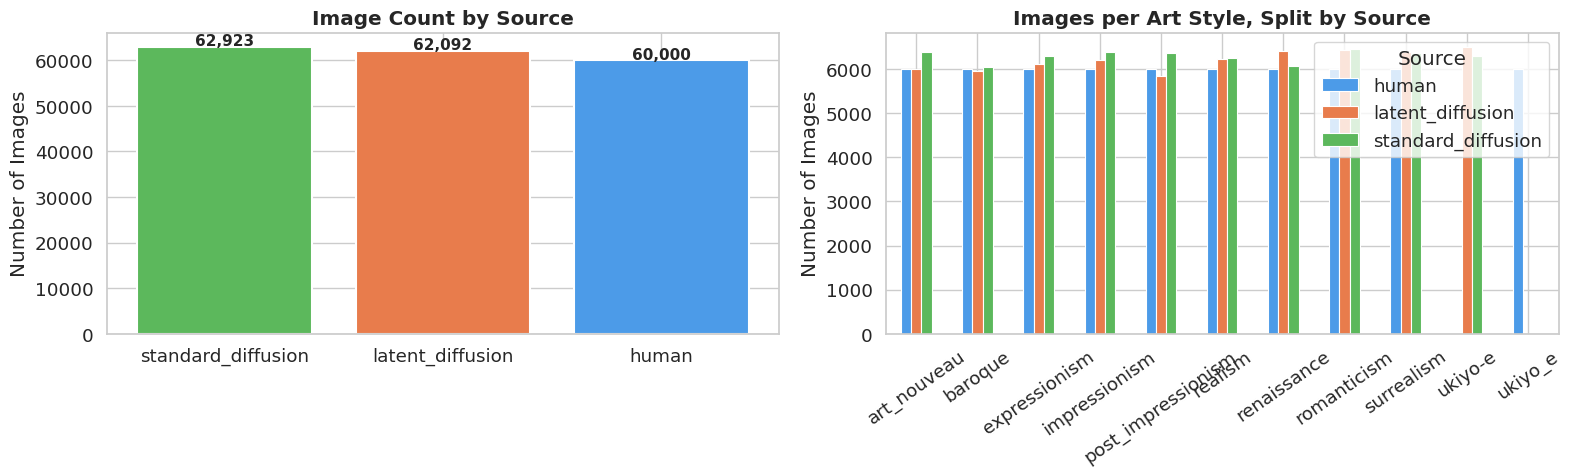

Saved → figures/01_class_distribution.png


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
COLORS = {'human': '#4C9BE8', 'latent_diffusion': '#E87C4C', 'standard_diffusion': '#5CB85C'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

src_counts = df['source'].value_counts()
bars = axes[0].bar(src_counts.index,
                   src_counts.values,
                   color=[COLORS[s] for s in src_counts.index],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Image Count by Source', fontweight='bold')
axes[0].set_ylabel('Number of Images')
for bar, val in zip(bars, src_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 300,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')


pivot = df.groupby(['style', 'source']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1],
           color=[COLORS[c] for c in pivot.columns],
           edgecolor='white', linewidth=0.8)
axes[1].set_title('Images per Art Style, Split by Source', fontweight='bold')
axes[1].set_ylabel('Number of Images')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Source')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/01_class_distribution.png')

## Sample image grid

Available styles: ['art_nouveau', 'baroque', 'expressionism', 'impressionism', 'post_impressionism', 'realism', 'renaissance', 'romanticism', 'surrealism', 'ukiyo-e', 'ukiyo_e']
Saved → /kaggle/working/figures/02_sample_grid_impressionism.png


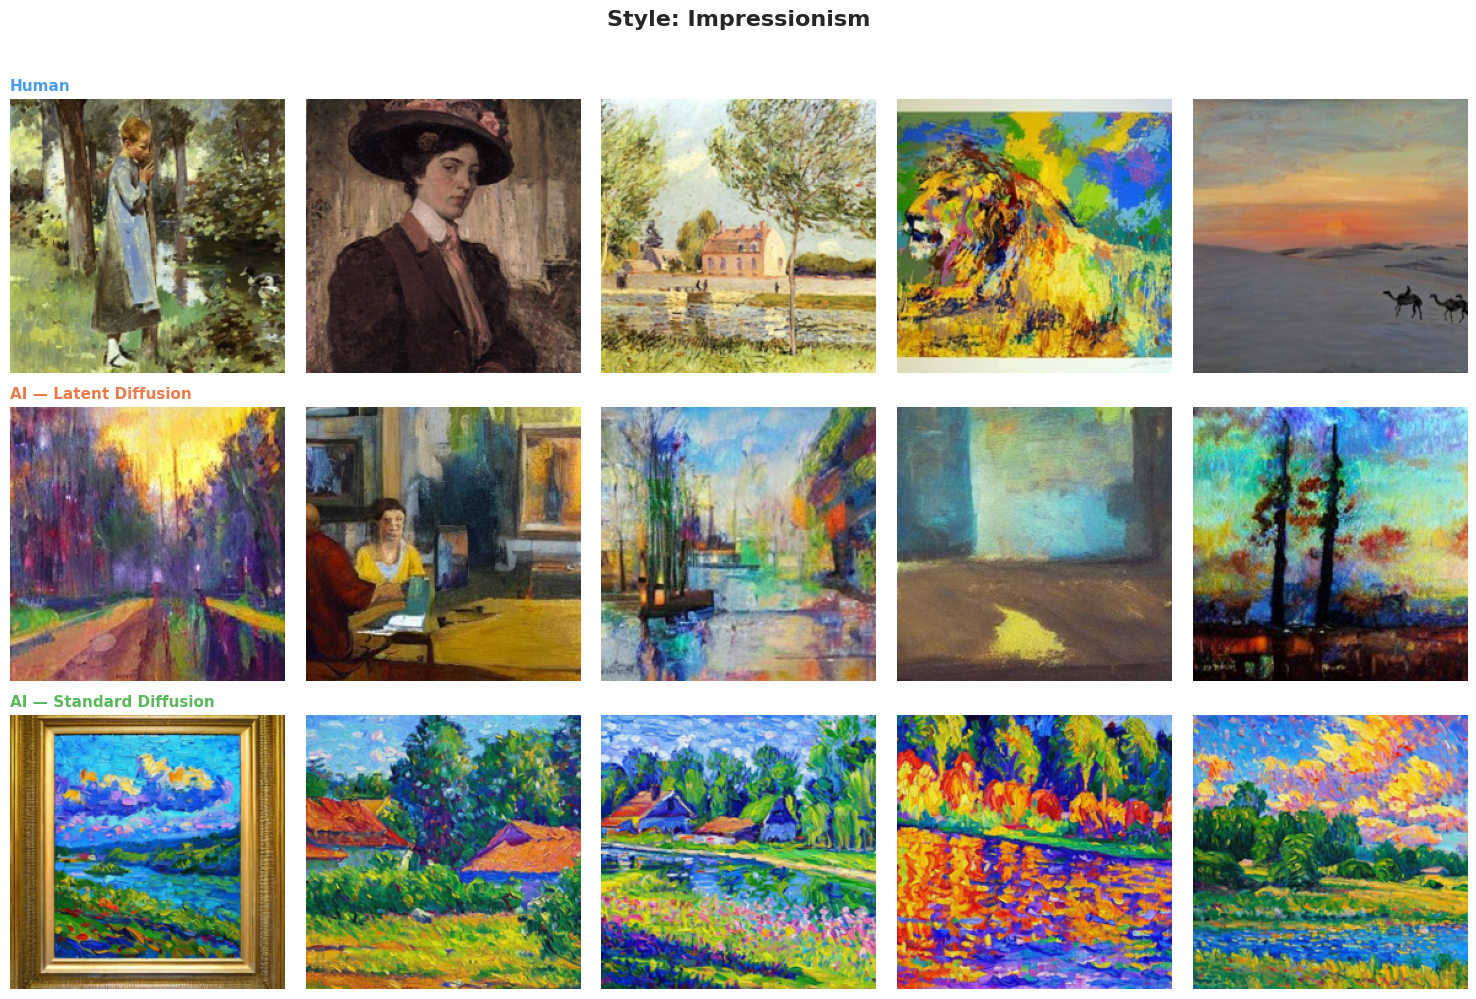

Saved → /kaggle/working/figures/02_sample_grid_surrealism.png


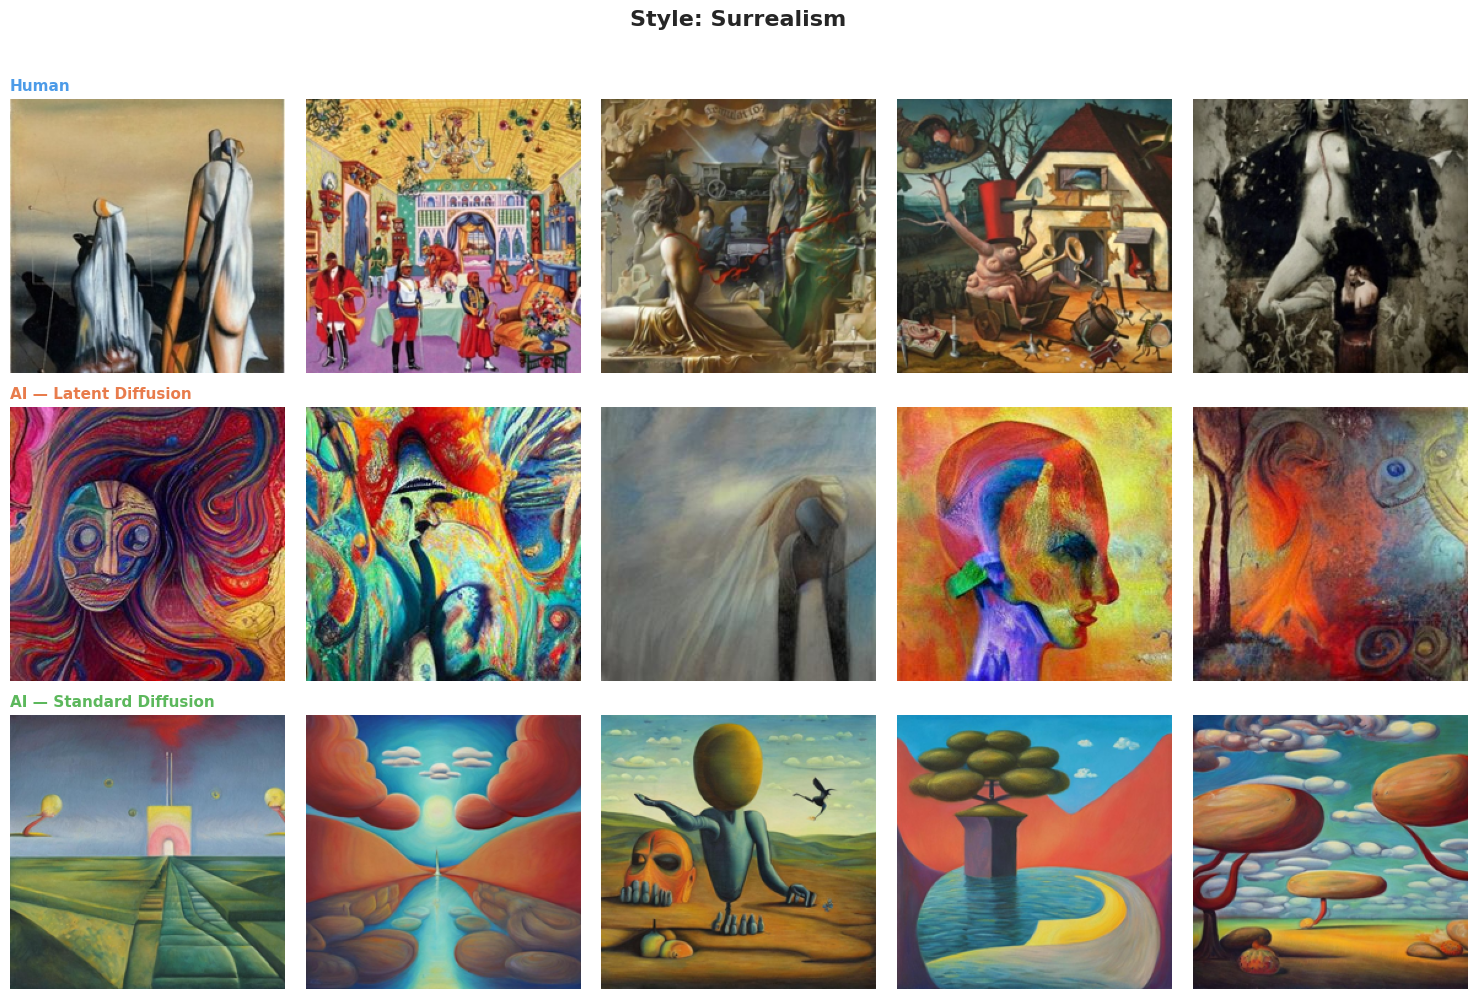

In [4]:
from PIL import Image
import numpy as np

def show_sample_grid(df, style, n_per_source=5, save_path=None):
    sources = ['human', 'latent_diffusion', 'standard_diffusion']
    labels  = ['Human', 'AI — Latent Diffusion', 'AI — Standard Diffusion']
    colors  = ['#4C9BE8', '#E87C4C', '#5CB85C']

    fig, axes = plt.subplots(3, n_per_source, figsize=(n_per_source * 3, 10))
    fig.suptitle(f'Style: {style.replace("_", " ").title()}',
                 fontsize=16, fontweight='bold', y=1.01)

    for row, (src, lbl, col) in enumerate(zip(sources, labels, colors)):
        subset = df[(df['source'] == src) & (df['style'] == style)]
        sample = subset.sample(n=min(n_per_source, len(subset)), random_state=42)
        for col_idx, (_, img_row) in enumerate(sample.iterrows()):
            img = Image.open(img_row['path']).convert('RGB').resize((224, 224))
            axes[row, col_idx].imshow(img)
            axes[row, col_idx].axis('off')
        
        axes[row, 0].set_title(lbl, fontsize=11, fontweight='bold', color=col, loc='left')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()

styles = sorted(df['style'].unique())
print('Available styles:', styles)


s1 = next((s for s in styles if 'impres' in s.lower()), styles[0])
s2 = next((s for s in styles if 'surreal' in s.lower()), styles[1])

show_sample_grid(df, s1, save_path=f'{FIG_DIR}/02_sample_grid_{s1}.png')
show_sample_grid(df, s2, save_path=f'{FIG_DIR}/02_sample_grid_{s2}.png')

## Image size statistics

In [5]:
import os

print(os.listdir("/kaggle/working"))

['__notebook__.ipynb', 'dataset_manifest.csv', 'figures']


In [6]:
import os

print(os.path.exists("/kaggle/working/dataset_manifest.csv"))
print(os.listdir("/kaggle/working"))

True
['__notebook__.ipynb', 'dataset_manifest.csv', 'figures']


In [7]:
from tqdm.notebook import tqdm
size_records = []
for source in df['source'].unique():
    sample = df[df['source'] == source].sample(n=300, random_state=42)
    for _, row in tqdm(sample.iterrows(), total=300, desc=source):
        try:
            img = Image.open(row['path'])
            w, h = img.size
            size_records.append({'source': source, 'width': w, 'height': h})
        except Exception:
            pass

size_df = pd.DataFrame(size_records)
print(size_df.groupby('source')[['width', 'height']].agg(['mean', 'min', 'max']))

latent_diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

standard_diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

human:   0%|          | 0/300 [00:00<?, ?it/s]

                    width           height          
                     mean  min  max   mean  min  max
source                                              
human               256.0  256  256  256.0  256  256
latent_diffusion    256.0  256  256  256.0  256  256
standard_diffusion  768.0  768  768  768.0  768  768


## Frequency-domain analysis (FFT)

In [8]:
def mean_fft_spectrum(df, source, n=300, size=256):
    subset = df[df['source'] == source].sample(n=n, random_state=42)
    accum  = np.zeros((size, size), dtype=np.float64)
    count  = 0
    for _, row in tqdm(subset.iterrows(), total=n, desc=f'FFT {source}'):
        try:
            img = Image.open(row['path']).convert('L').resize((size, size))
            arr = np.array(img, dtype=np.float64)
            mag = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(arr))))
            accum += mag
            count += 1
        except Exception:
            pass
    return accum / max(count, 1)

sources = ['human', 'latent_diffusion', 'standard_diffusion']
spectra = {s: mean_fft_spectrum(df, s) for s in sources}

FFT human:   0%|          | 0/300 [00:00<?, ?it/s]

FFT latent_diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

FFT standard_diffusion:   0%|          | 0/300 [00:00<?, ?it/s]

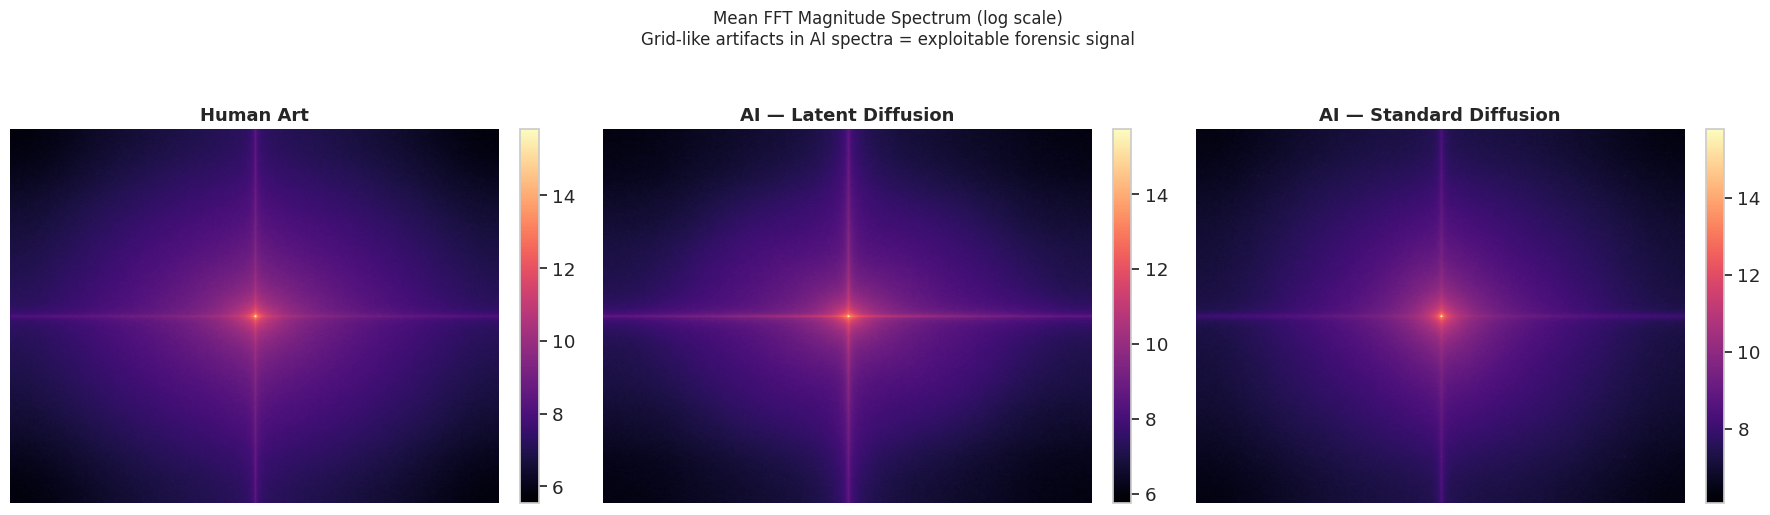

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Human Art', 'AI — Latent Diffusion', 'AI — Standard Diffusion']

for ax, src, title in zip(axes, sources, titles):
    im = ax.imshow(spectra[src], cmap='magma', aspect='auto')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Mean FFT Magnitude Spectrum (log scale)\nGrid-like artifacts in AI spectra = exploitable forensic signal',
             fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_fft_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

## Pixel intensity distributions

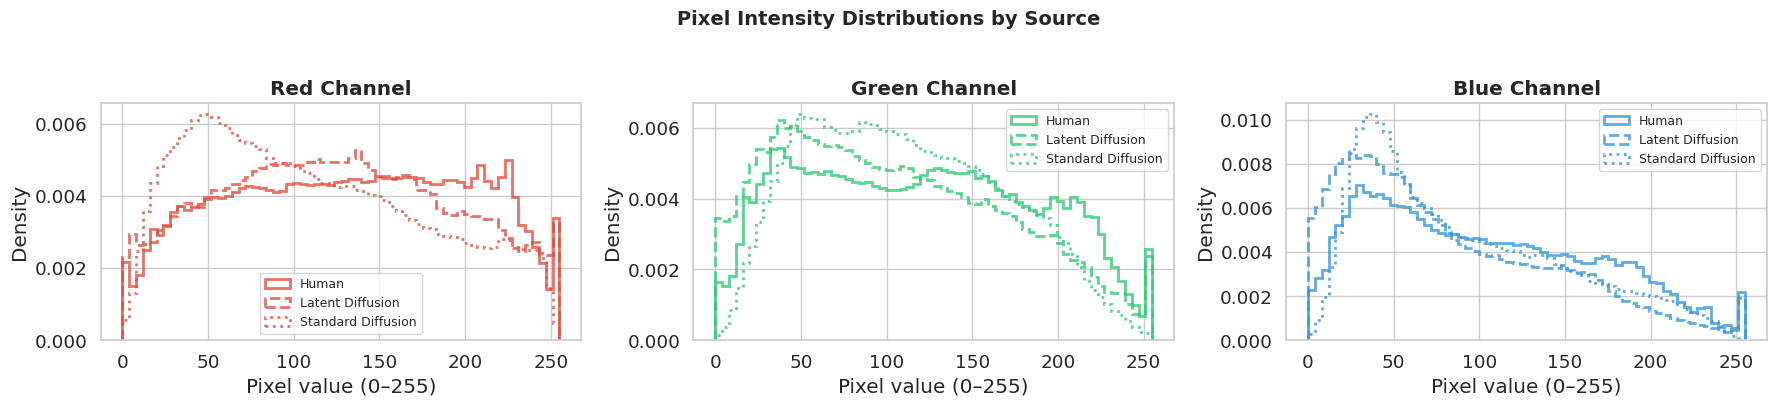

In [10]:
def channel_pixels(df, source, n=200, size=128):
    subset = df[df['source'] == source].sample(n=n, random_state=42)
    R, G, B = [], [], []
    for _, row in subset.iterrows():
        try:
            arr = np.array(Image.open(row['path']).convert('RGB').resize((size, size)))
            R.append(arr[:,:,0].flatten())
            G.append(arr[:,:,1].flatten())
            B.append(arr[:,:,2].flatten())
        except Exception:
            pass
    return np.concatenate(R), np.concatenate(G), np.concatenate(B)

hist_data = {s: channel_pixels(df, s) for s in sources}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ch_names  = ['Red', 'Green', 'Blue']
ch_colors = ['#E74C3C', '#2ECC71', '#3498DB']
src_labels = ['Human', 'Latent Diffusion', 'Standard Diffusion']
src_ls     = ['-', '--', ':']

for ax, ch_name, ch_color, ch_idx in zip(axes, ch_names, ch_colors, range(3)):
    for src, lbl, ls in zip(sources, src_labels, src_ls):
        ax.hist(hist_data[src][ch_idx], bins=64, density=True,
                histtype='step', linewidth=2, linestyle=ls,
                color=ch_color, alpha=0.8, label=lbl)
    ax.set_title(f'{ch_name} Channel', fontweight='bold')
    ax.set_xlabel('Pixel value (0–255)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Pixel Intensity Distributions by Source', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_pixel_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [11]:
print(f'Total images          : {len(df):,}')
print(f'Human art             : {(df.source=="human").sum():,}')
print(f'AI (Latent Diffusion) : {(df.source=="latent_diffusion").sum():,}')
print(f'AI (Std Diffusion)    : {(df.source=="standard_diffusion").sum():,}')
print(f'Art styles            : {df["style"].nunique()}')
print(f'Binary split          : {(df.label==0).sum():,} real / {(df.label==1).sum():,} AI')
print()
print('Files saved to /kaggle/working/:')
for f in sorted(os.listdir(OUT_DIR)):
    print(f'  {f}')


Total images          : 185,015
Human art             : 60,000
AI (Latent Diffusion) : 62,092
AI (Std Diffusion)    : 62,923
Art styles            : 11
Binary split          : 60,000 real / 125,015 AI

Files saved to /kaggle/working/:
  __notebook__.ipynb
  dataset_manifest.csv
  figures
